<a href="https://colab.research.google.com/github/supunabeywickrama/my-colab-work/blob/main/fabric_yolov8_colab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fabric Defect Detection — YOLOv8 Training (Colab)

5 classes: `hole, broken_end, slub, oil_stain, streak`  ·  ~4256 images, source-batch 70/15/15 split.

**Goal:** high accuracy AND high recall (in QC, a missed defect is worse than a false alarm).

**Before you start:** Runtime → Change runtime type → **GPU** (T4 is fine; A100 if you have Pro).

In [ ]:
!pip install -q -U "numpy>=2.0" ultralytics
import os
print("Forcing runtime restart to reload NumPy... (you'll see a 'session crashed' notice — that's expected)")
os.kill(os.getpid(), 9)



In [1]:
import numpy, torch
print("numpy", numpy.__version__, "| torch", torch.__version__, "| CUDA", torch.cuda.is_available())
from ultralytics import YOLO
print("import OK ✓")


numpy 2.4.6 | torch 2.11.0+cu128 | CUDA True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
import OK ✓


In [1]:
!pip install -q -U ultralytics
import ultralytics, torch, numpy
ultralytics.checks()
print('numpy:', numpy.__version__, '| torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 49.3/235.7 GB disk)
numpy: 2.4.6 | torch: 2.11.0+cu128 | CUDA: True


In [1]:
import numpy, ultralytics, torch
print('numpy:', numpy.__version__, '| torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
assert numpy.__version__.startswith('2'), "NumPy still 1.x — re-run Cell A and restart"
ultralytics.checks()


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 49.3/235.7 GB disk)


## 1. GPU check + install

In [2]:
!nvidia-smi
!pip -q install ultralytics==8.3.0
import ultralytics, torch
ultralytics.checks()
print('CUDA available:', torch.cuda.is_available())

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 47.6/235.7 GB disk)
CUDA available: True


## 2. Mount Drive + unzip dataset
Edit `ZIP_ON_DRIVE` to where you uploaded `fabric_dataset_v1.zip`.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, time
ZIP_ON_DRIVE = '/content/drive/MyDrive/fabric_dataset_v1.zip'   # <-- edit if your path differs
EXTRACT_TO   = '/content'

assert os.path.exists(ZIP_ON_DRIVE), f'Not found: {ZIP_ON_DRIVE}'
t = time.time()
with zipfile.ZipFile(ZIP_ON_DRIVE) as z:
    z.extractall(EXTRACT_TO)
print(f'unzipped in {time.time()-t:.0f}s')

DATA_DIR  = '/content/fabric_dataset'
DATA_YAML = f'{DATA_DIR}/dataset.yaml'
print(open(DATA_YAML).read())


Mounted at /content/drive
unzipped in 16s
# Portable dataset config (generated by src/make_release.py)
path: .
train: images/train
val: images/val
test: images/test
names:
  0: hole
  1: broken_end
  2: slub
  3: oil_stain
  4: streak



## 3. Make the dataset.yaml path absolute (Colab-safe)
The packaged yaml uses `path: .`; we pin it to the real unzip location so Ultralytics never guesses.

In [4]:
import yaml, os
with open(DATA_YAML) as f:
    d = yaml.safe_load(f)
d['path'] = DATA_DIR
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(d, f, sort_keys=False)
print(d)
for s in ['train','val','test']:
    print(f'{s:5s}: {len(os.listdir(f"{DATA_DIR}/images/{s}"))} images')


{'path': '/content/fabric_dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'hole', 1: 'broken_end', 2: 'slub', 3: 'oil_stain', 4: 'streak'}}
train: 2936 images
val  : 682 images
test : 638 images


## 4. Train — recall-tuned config

Key choices and *why*:
- **yolov8m** — best accuracy/speed balance on a T4. Use `yolov8l.pt` if you have an A100.
- **imgsz=960** — fabric defects (thin streaks, small holes) are tiny; higher resolution is the single biggest recall lever.
- **flipud+fliplr=0.5** — fabric has no canonical orientation, so both flips are safe and double effective data.
- **mosaic + mixup + copy_paste** — aggressive aug fights overfitting on the smaller classes.
- **close_mosaic=15** — turn mosaic off for the last 15 epochs so the model converges on real (un-tiled) images.
- **cos_lr + patience=40** — smooth decay, early-stop when val plateaus.

In [6]:
!pip install -q -U ultralytics


In [8]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')

results = model.train(
    data=DATA_YAML,
    epochs=200,
    patience=40,
    imgsz=960,
    batch=-1,            # auto-batch to fill ~60% VRAM; set 16 if it OOMs
    optimizer='AdamW',
    lr0=0.002,
    cos_lr=True,
    # --- augmentation ---
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0, translate=0.1, scale=0.5, shear=2.0,
    fliplr=0.5, flipud=0.5,
    mosaic=1.0, close_mosaic=15, mixup=0.10, copy_paste=0.10,
    # --- bookkeeping ---
    project='/content/drive/MyDrive/fabric_runs',
    name='yolov8m_960_recall',
    exist_ok=True,
    seed=1337,
    plots=True,
)
print('Best weights:', model.trainer.best)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/fabric_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_960_recall, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW

ModuleNotFoundError: No module named 'numpy.char'

## 5. Evaluate on the held-out TEST split
Reports per-class P / R / mAP and saves confusion-matrix + PR curves.

In [9]:
best = YOLO(model.trainer.best)
metrics = best.val(data=DATA_YAML, split='test', imgsz=960, conf=0.001, iou=0.6, plots=True)
print('mAP50    :', round(metrics.box.map50, 4))
print('mAP50-95 :', round(metrics.box.map, 4))
names = best.names
for i, c in enumerate(names.values()):
    print(f'{c:12s}  P={metrics.box.p[i]:.3f}  R={metrics.box.r[i]:.3f}  mAP50={metrics.box.ap50[i]:.3f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1801.0±1168.0 MB/s, size: 223.5 KB)
val: Scanning /content/fabric_dataset/labels/test... 638 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 828.2it/s 0.8s
val: /content/fabric_dataset/images/test/kaggle_01_20180531_134722_32565340.jpg: corrupt JPEG restored and saved
val: /content/fabric_dataset/images/test/kaggle_01_20180531_134730_d0d48924.jpg: corrupt JPEG restored and saved
val: /content/fabric_dataset/images/test/kaggle_01_20180531_135129(1)_28143f43.jpg: corrupt JPEG restored and saved
val: /content/fabric_dataset/images/test/kaggle_01_20180531_135709_a601f19c.jpg: corrupt JPEG restored and saved
val: /content/fabric_dataset/images/test/kaggle_01_20180531_140300(1)_bf43751d.jpg: corrupt JPEG restored and saved
val: /content/fabric_dataset/imag

## 6. Pick the confidence threshold for a RECALL target
QC priority: catch defects. We sweep confidence on the **val** split and pick the
lowest-conf operating point that still keeps precision reasonable, targeting recall ≥ 0.90.

In [10]:
import numpy as np
TARGET_RECALL = 0.90
rows = []
for conf in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    m = best.val(data=DATA_YAML, split='val', imgsz=960, conf=conf, iou=0.6, verbose=False, plots=False)
    rows.append((conf, float(m.box.mp), float(m.box.mr), float(m.box.map50)))
    print(f'conf={conf:.2f}  P={m.box.mp:.3f}  R={m.box.mr:.3f}  mAP50={m.box.map50:.3f}')

ok = [r for r in rows if r[2] >= TARGET_RECALL]
chosen = max(ok, key=lambda r: r[1]) if ok else max(rows, key=lambda r: r[2])
DEPLOY_CONF = chosen[0]
print(f'\n>>> deploy conf = {DEPLOY_CONF}  (P={chosen[1]:.3f}, R={chosen[2]:.3f})')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2095.0±1199.4 MB/s, size: 60.2 KB)
val: Scanning /content/fabric_dataset/labels/val.cache... 682 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 682/682 178.8Mit/s 0.0s
val: /content/fabric_dataset/images/val/kaggle_01_20180531_135032(1)_57f1ea3e.jpg: corrupt JPEG restored and saved
val: /content/fabric_dataset/images/val/kaggle_01_20180531_135111_535440cb.jpg: corrupt JPEG restored and saved
val: /content/fabric_dataset/images/val/kaggle_01_20180531_140818_25b9d3a0.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 7.9it/s 5.4s
                   all        682        965      0.604      0.511      0.502      0.335
Speed: 1.0ms preprocess, 4.2ms inference, 0.0ms loss, 0.9ms postprocess per image
conf=0.05  P=0.604  R=0.511  mAP50=0.502
Ult

## 7. Export for real-time inference

In [11]:
# ONNX = portable; TensorRT (engine) = fastest on NVIDIA edge devices.
best.export(format='onnx', imgsz=960, dynamic=True, simplify=True)
# best.export(format='engine', imgsz=960, half=True)   # uncomment on a TensorRT-capable GPU

import shutil
shutil.copy(model.trainer.best, '/content/drive/MyDrive/fabric_runs/best.pt')
print('Saved best.pt + best.onnx to Drive. Use DEPLOY_CONF =', DEPLOY_CONF)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/fabric_runs/yolov8m_960_recall/weights/best.pt' with input shape (1, 3, 960, 960) BCHW and output shape(s) (1, 9, 18900) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 229ms
Prepared 4 packages in 1.39s
Installed 4 packages in 238ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 7.1s, sav

## 8. Quick visual smoke test


0: 960x960 2 slubs, 12.1ms
1: 960x960 1 oil_stain, 12.1ms
2: 960x960 1 broken_end, 12.1ms
3: 960x960 1 hole, 12.1ms
4: 960x960 1 broken_end, 12.1ms
5: 960x960 2 broken_ends, 12.1ms
Speed: 5.2ms preprocess, 12.1ms inference, 1.0ms postprocess per image at shape (1, 3, 960, 960)
Results saved to /content/runs/detect/predict


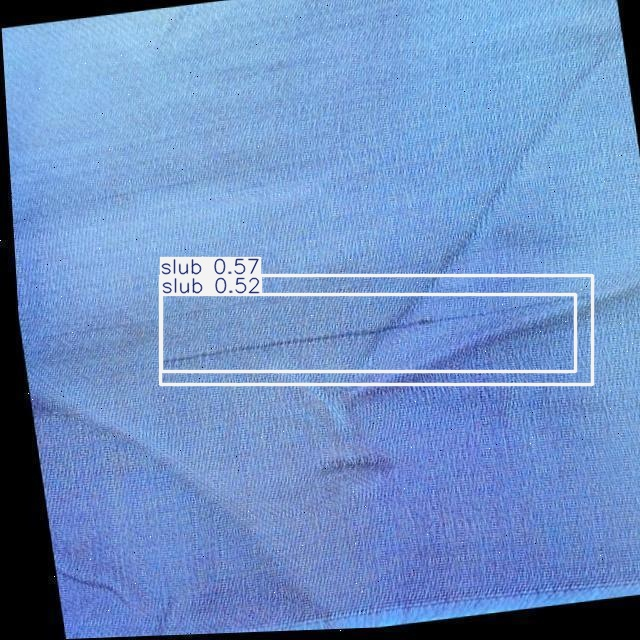

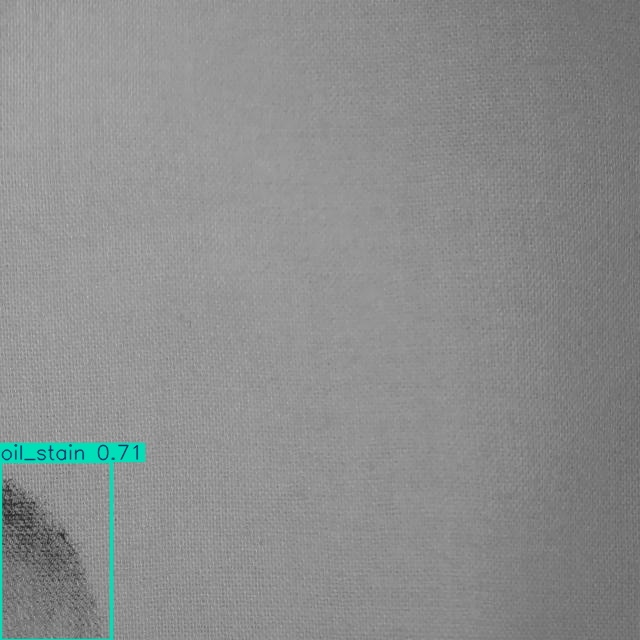

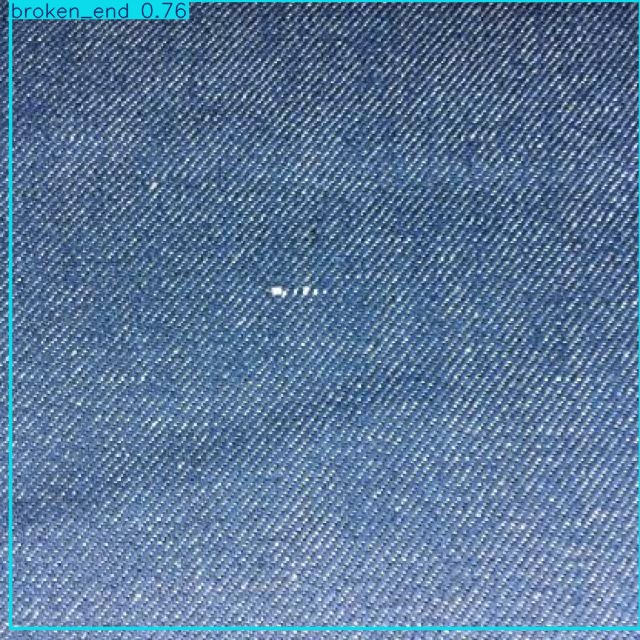

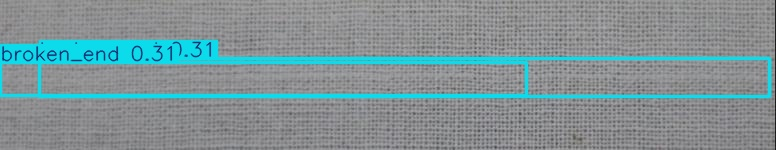

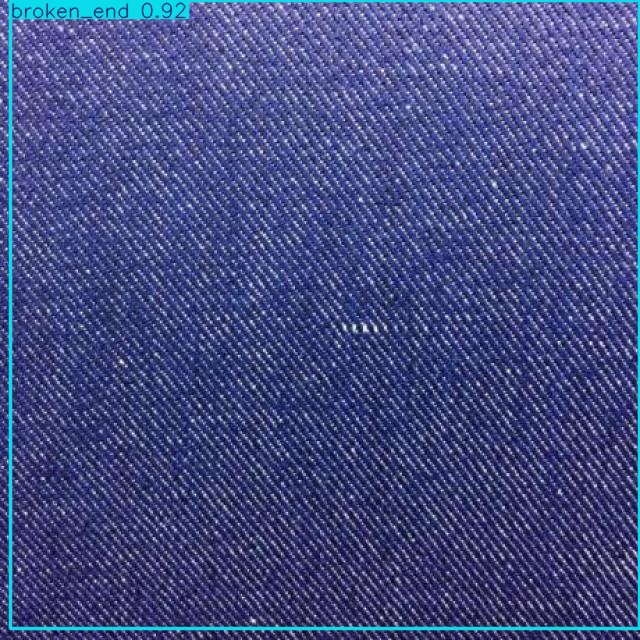

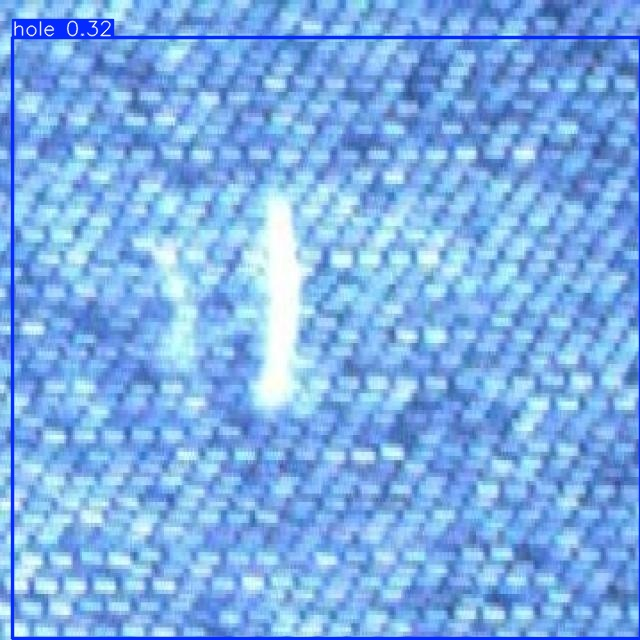

In [12]:
import glob, random
from IPython.display import Image, display
samples = random.sample(glob.glob(f'{DATA_DIR}/images/test/*'), 6)
pred = best.predict(samples, imgsz=960, conf=DEPLOY_CONF, save=True)
for p in glob.glob(f'{pred[0].save_dir}/*')[:6]:
    display(Image(p, width=480))